# Full BNS + NSBH likelihood

This notebook runs the six-parameter joint likelihood directly. It does **not** load a BNS-only backend or use a KDE posterior as a prior. For each run, $f_j^{\rm BNS}$, the geometry-efficiency function, $\alpha_{\rm CE}$, and the NSBH population are fixed; the spectral parameters and both opening angles are sampled.

In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

plt.style.use('../../../configurations/style.mplstyle')

from mcmc_runny import (
    N_PARAMS,
    _backend_path,
    collect_rate_posteriors,
    plot_corner,
    plot_posterior_grid,
    run_pop,
)
from src.top_hat.geometric_eff import geometric_efficiency_flat_midpoint, geometric_efficiency_fixed, create_geometric_efficiency_lognormal_interpolator
interp_ln = create_geometric_efficiency_lognormal_interpolator()
def geometric_efficiency_lognormal(theta): return interp_ln(theta)

print(f'Imports complete; this model samples {N_PARAMS} parameters.')

Imports complete; this model samples 7 parameters.


## Run configuration

Edit `FJ_LIST` and `NSBH_POPULATIONS` before launching the chains. Every combination gets its own resumable `emcee.h5` backend.

In [45]:
DATAFILES       = Path('../../../datafiles')
IMAGES_FOLDER   = Path('Images')
IMAGES_FOLDER.mkdir(parents=True, exist_ok=True)

POSSIBLE_ALPHA      = ['A3.0', 'A5.0']#, 'A1.0']
FJ_LIST             = [0.1, 0.5, 1.0]#, 1.0]  # fixed value for each independent run
POPULATION          = "qcbse"
NSBH_SERIES         = [
    'NSBH_DD2_uniform_chi_0_1',
    'NSBH_SFHo_uniform_chi_0_1',
]
SERIES_LABELS = [
    r"DD2, $\chi \sim \mathcal{U}(0,1)$",
    r"SFHo, $\chi \sim \mathcal{U}(0,1)$",
]
GEOM_EFF_FUNC   = geometric_efficiency_flat_midpoint
GEOM_NAME       = GEOM_EFF_FUNC.__name__
GEOM_LABEL_DIC = {
    "geometric_efficiency_flat_midpoint": "midpoint",
    "geometric_efficiency_fixed": "fixed",
    "geometric_efficiency_lognormal": "lognormal",
}
GEOM_LABEL_CURRENT = GEOM_LABEL_DIC[GEOM_NAME]
N_WALKERS       = 24
N_STEPS         = 20_000
N_EVENTS        = None  # None uses mcmc_runny.N_MC_EVENTS
SEED            = 123

In [47]:
MRD_FOLDER = DATAFILES / "MRD_outputs"
required_mrd_files = set()

for alpha in POSSIBLE_ALPHA:
    alpha_file = alpha.replace(".", "_")

    required_mrd_files.add(
        MRD_FOLDER / f"{POPULATION}_{alpha_file}_BNS.csv"
    )

    for nsbh_series in NSBH_SERIES:
        required_mrd_files.add(
            MRD_FOLDER / f"{POPULATION}_{alpha_file}_{nsbh_series}.csv"
        )

missing_mrd_files = [
    path for path in sorted(required_mrd_files)
    if not path.is_file()
]

if missing_mrd_files:
    # list all csv files in the MRD folder
    print(f"MRD folder contents: {sorted(MRD_FOLDER.glob('*.csv'))}")
    raise FileNotFoundError(
        "The following MRD files are missing:\n"
        + "\n".join(str(path) for path in missing_mrd_files)
    )

print(f"Found all {len(required_mrd_files)} required MRD files.")

Found all 6 required MRD files.


## Run or resume all chains

The initial walkers are generated inside the flat-prior support; no previous chain is read. Re-running this cell resumes matching backends up to `N_STEPS`.

In [16]:
backend_paths = {}

for nsbh_series in NSBH_SERIES:
    for fj_bns in FJ_LIST:
        run_kwargs = {
            "alphas"        : POSSIBLE_ALPHA,
            "fj_bns"        : fj_bns,
            "geom_eff_func" : GEOM_EFF_FUNC,
            "datafiles"     : DATAFILES,
            "population"    : POPULATION,
            "nsbh_series"   : nsbh_series,
            "n_params"      : N_PARAMS,
            "n_walkers"     : N_WALKERS,
            "n_steps"       : N_STEPS,
            "seed"          : SEED,
        }

        if N_EVENTS is not None:
            run_kwargs["n_events"] = N_EVENTS

        paths = run_pop(**run_kwargs)

        for alpha, path in zip(POSSIBLE_ALPHA, paths):
            backend_paths[(fj_bns, alpha, nsbh_series)] = path

backend_paths

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=10000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=5.06 Gpc^-3 yr^-1; all-sky rate=7.750e+03 yr^-1; MC sample=10000
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Already completed this run
alpha=A3.0; fj_bns=0.1; geometry=geometric-efficiency-flat-midpoint; population=qcbse; nsbh_series=NSBH_DD2_uniform_chi_0_1; remaining steps=0
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=9.52 Gpc^-3 yr^-1; all-sky rate=2.106e+04 yr^-1; MC sample=10000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=4.59 Gpc^-3 yr^-1; all-sky rate

100%|██████████| 20000/20000 [32:23<00:00, 10.29it/s]


Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=9.52 Gpc^-3 yr^-1; all-sky rate=2.106e+04 yr^-1; MC sample=10000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=4.59 Gpc^-3 yr^-1; all-sky rate=6.426e+03 yr^-1; MC sample=10000
Creating new directory : Output_files/full_likelihood_alpha_A5.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Starting new run from starting point
alpha=A5.0; fj_bns=0.5; geometry=geometric-efficiency-flat-midpoint; population=qcbse; nsbh_series=NSBH_DD2_uniform_chi_0_1; remaining steps=20000


100%|██████████| 20000/20000 [29:57<00:00, 11.13it/s]


Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=10000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=5.06 Gpc^-3 yr^-1; all-sky rate=7.750e+03 yr^-1; MC sample=10000
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Already completed this run
alpha=A3.0; fj_bns=1; geometry=geometric-efficiency-flat-midpoint; population=qcbse; nsbh_series=NSBH_DD2_uniform_chi_0_1; remaining steps=0
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=9.52 Gpc^-3 yr^-1; all-sky rate=2.106e+04 yr^-1; MC sample=10000
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=4.59 Gpc^-3 yr^-1; all-sky rate=6.4

...

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=9.52 Gpc^-3 yr^-1; all-sky rate=2.106e+04 yr^-1; MC sample=10000
NSBH_SFHo_uniform_chi_0_1: R(z=0.01)=3.48 Gpc^-3 yr^-1; all-sky rate=4.888e+03 yr^-1; MC sample=10000
Creating new directory : Output_files/full_likelihood_alpha_A5.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Starting new run from starting point
alpha=A5.0; fj_bns=0.5; geometry=geometric-efficiency-flat-midpoint; population=qcbse; nsbh_series=NSBH_SFHo_uniform_chi_0_1; remaining steps=20000


100%|██████████| 20000/20000 [30:35<00:00, 10.90it/s]


Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=10000
NSBH_SFHo_uniform_chi_0_1: R(z=0.01)=3.85 Gpc^-3 yr^-1; all-sky rate=5.906e+03 yr^-1; MC sample=10000
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Already completed this run
alpha=A3.0; fj_bns=1; geometry=geometric-efficiency-flat-midpoint; population=qcbse; nsbh_series=NSBH_SFHo_uniform_chi_0_1; remaining steps=0
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=9.52 Gpc^-3 yr^-1; all-sky rate=2.106e+04 yr^-1; MC sample=10000
NSBH_SFHo_uniform_chi_0_1: R(z=0.01)=3.48 Gpc^-3 yr^-1; all-sky rate

100%|██████████| 4254/4254 [06:16<00:00, 11.31it/s]


{(0.1,
  'A3.0',
  'NSBH_DD2_uniform_chi_0_1'): PosixPath('Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1/emcee.h5'),
 (0.1,
  'A5.0',
  'NSBH_DD2_uniform_chi_0_1'): PosixPath('Output_files/full_likelihood_alpha_A5.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1/emcee.h5'),
 (0.5,
  'A3.0',
  'NSBH_DD2_uniform_chi_0_1'): PosixPath('Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1/emcee.h5'),
 (0.5,
  'A5.0',
  'NSBH_DD2_uniform_chi_0_1'): PosixPath('Output_files/full_likelihood_alpha_A5.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1/emcee.h5'),
 (1.0,
  'A3.0',
  'NSBH_DD2_uniform_chi_0_1'): PosixPath('Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1/emcee.h5'),
 (1.0,
  'A5.0',
  'NSBH_DD2_uniform_chi_0_1'): PosixPath('Output_files/full_likel

## Six-parameter corner plots

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1


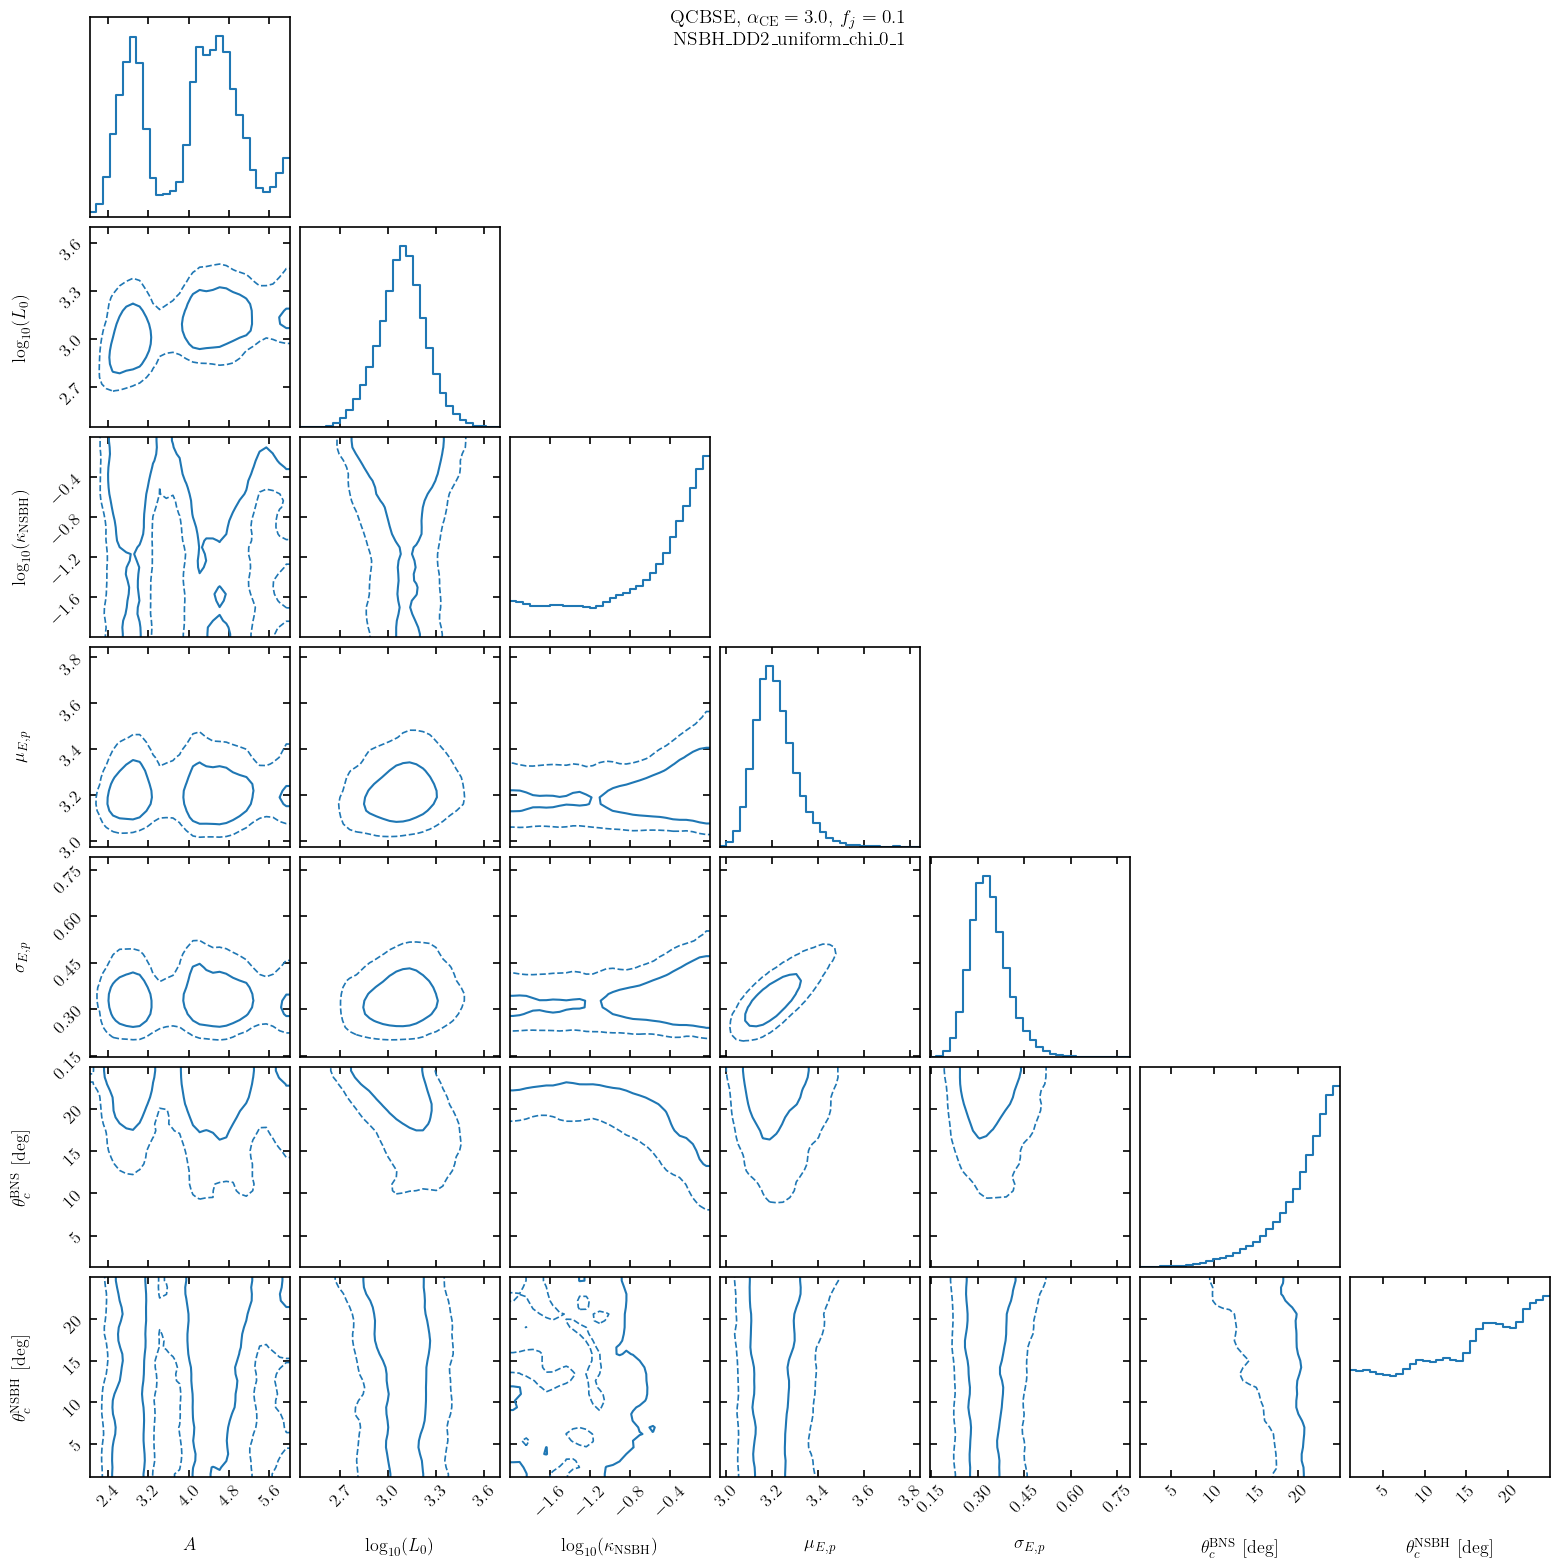

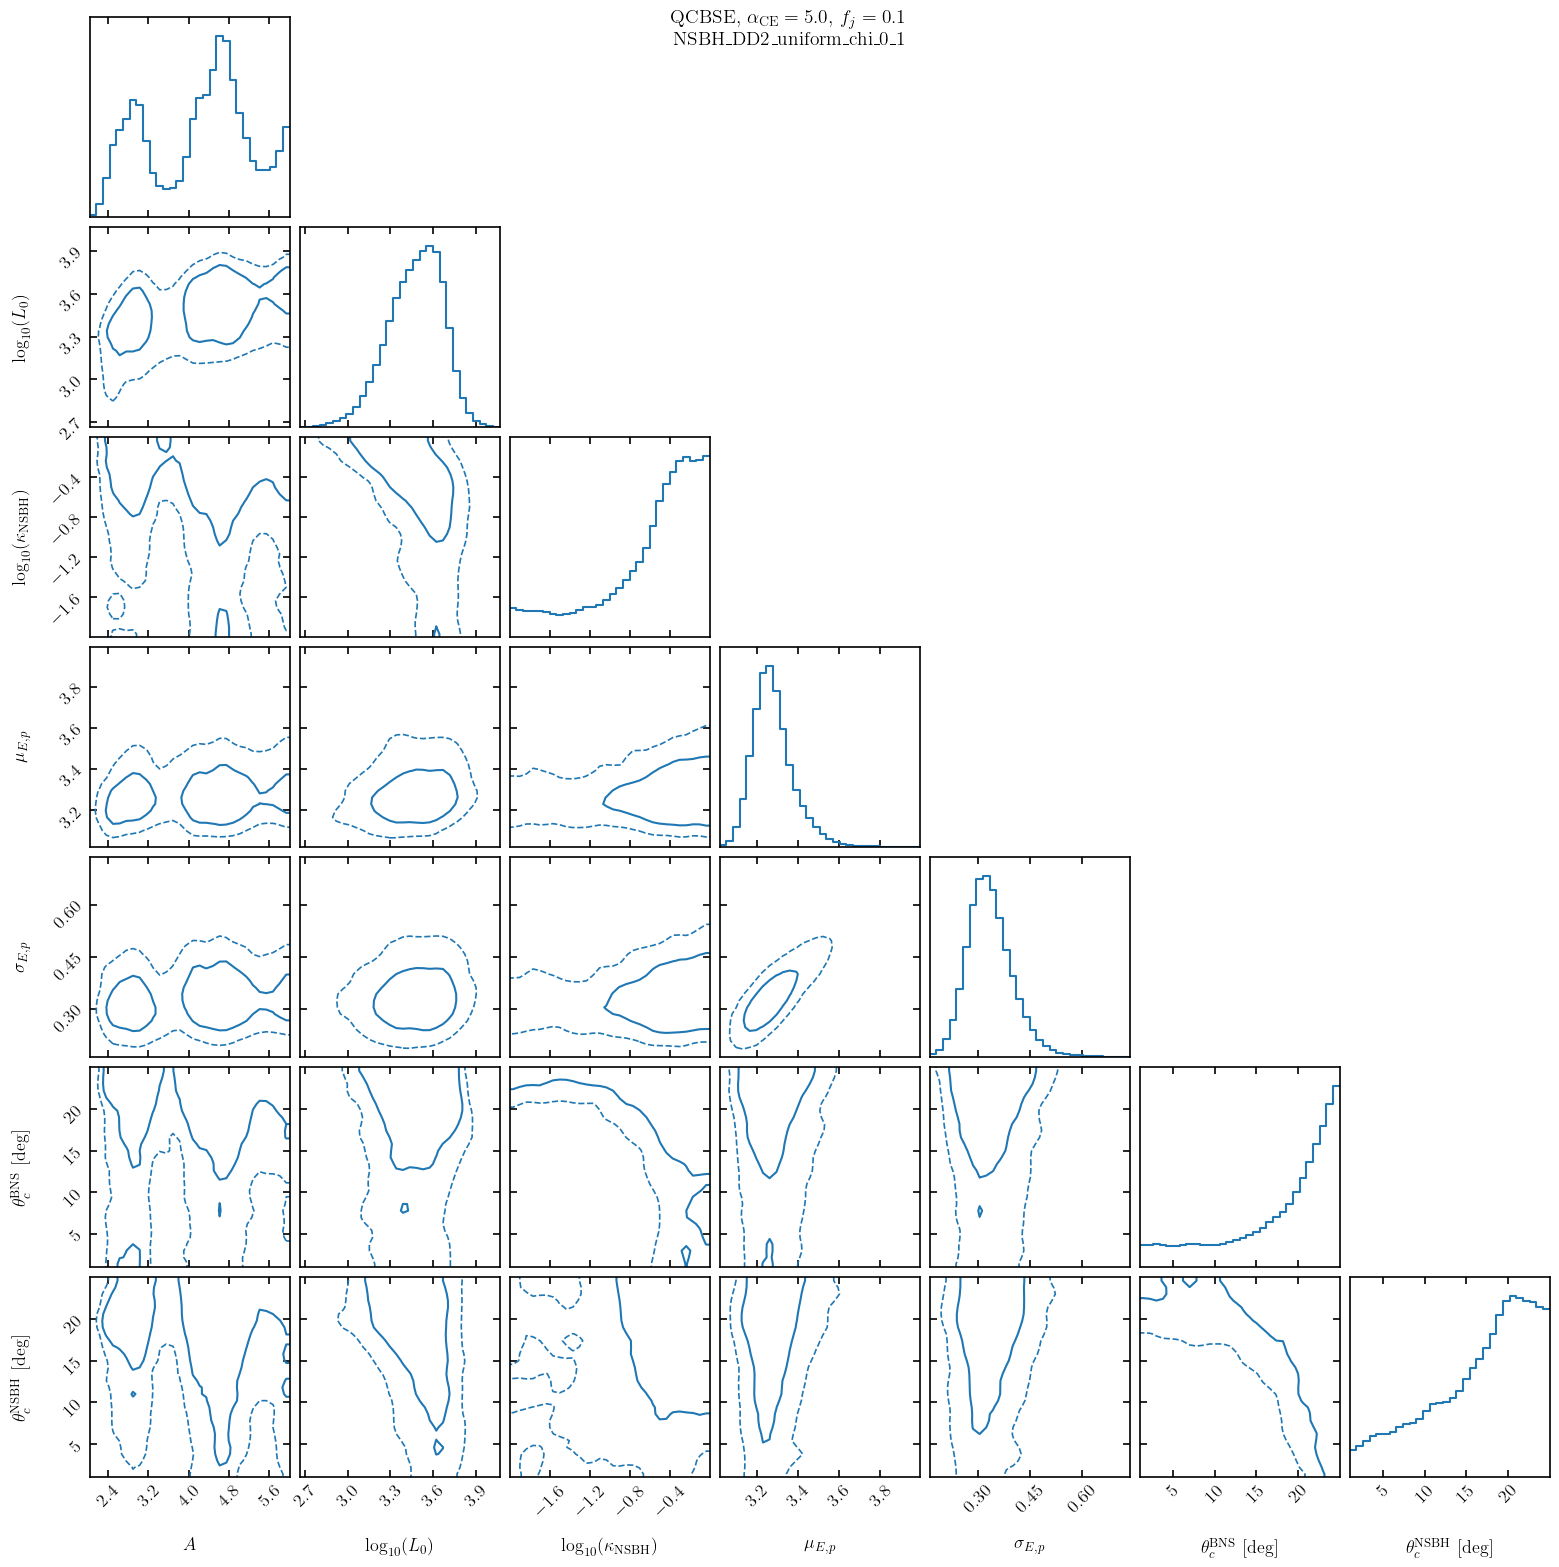

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1


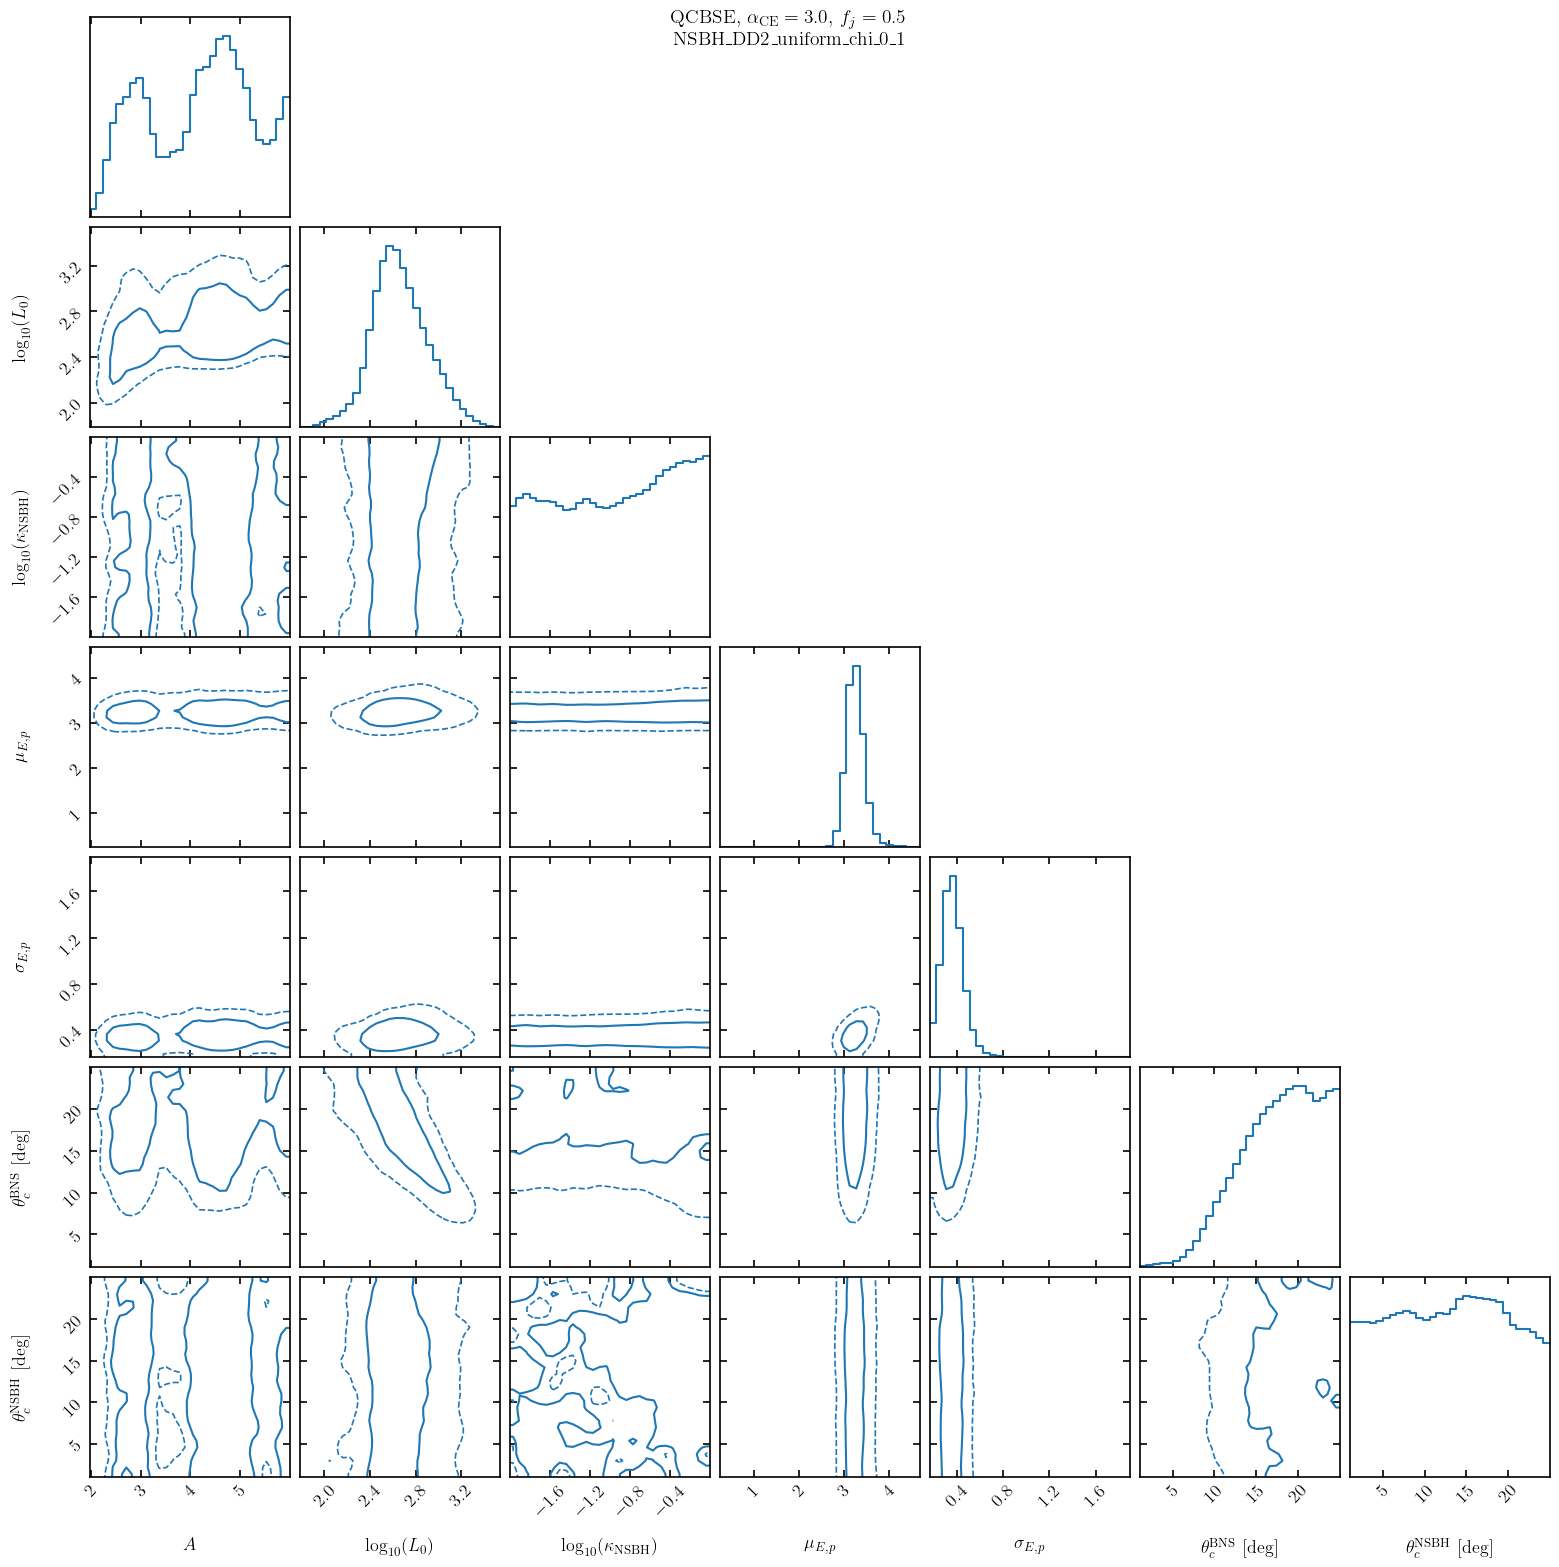

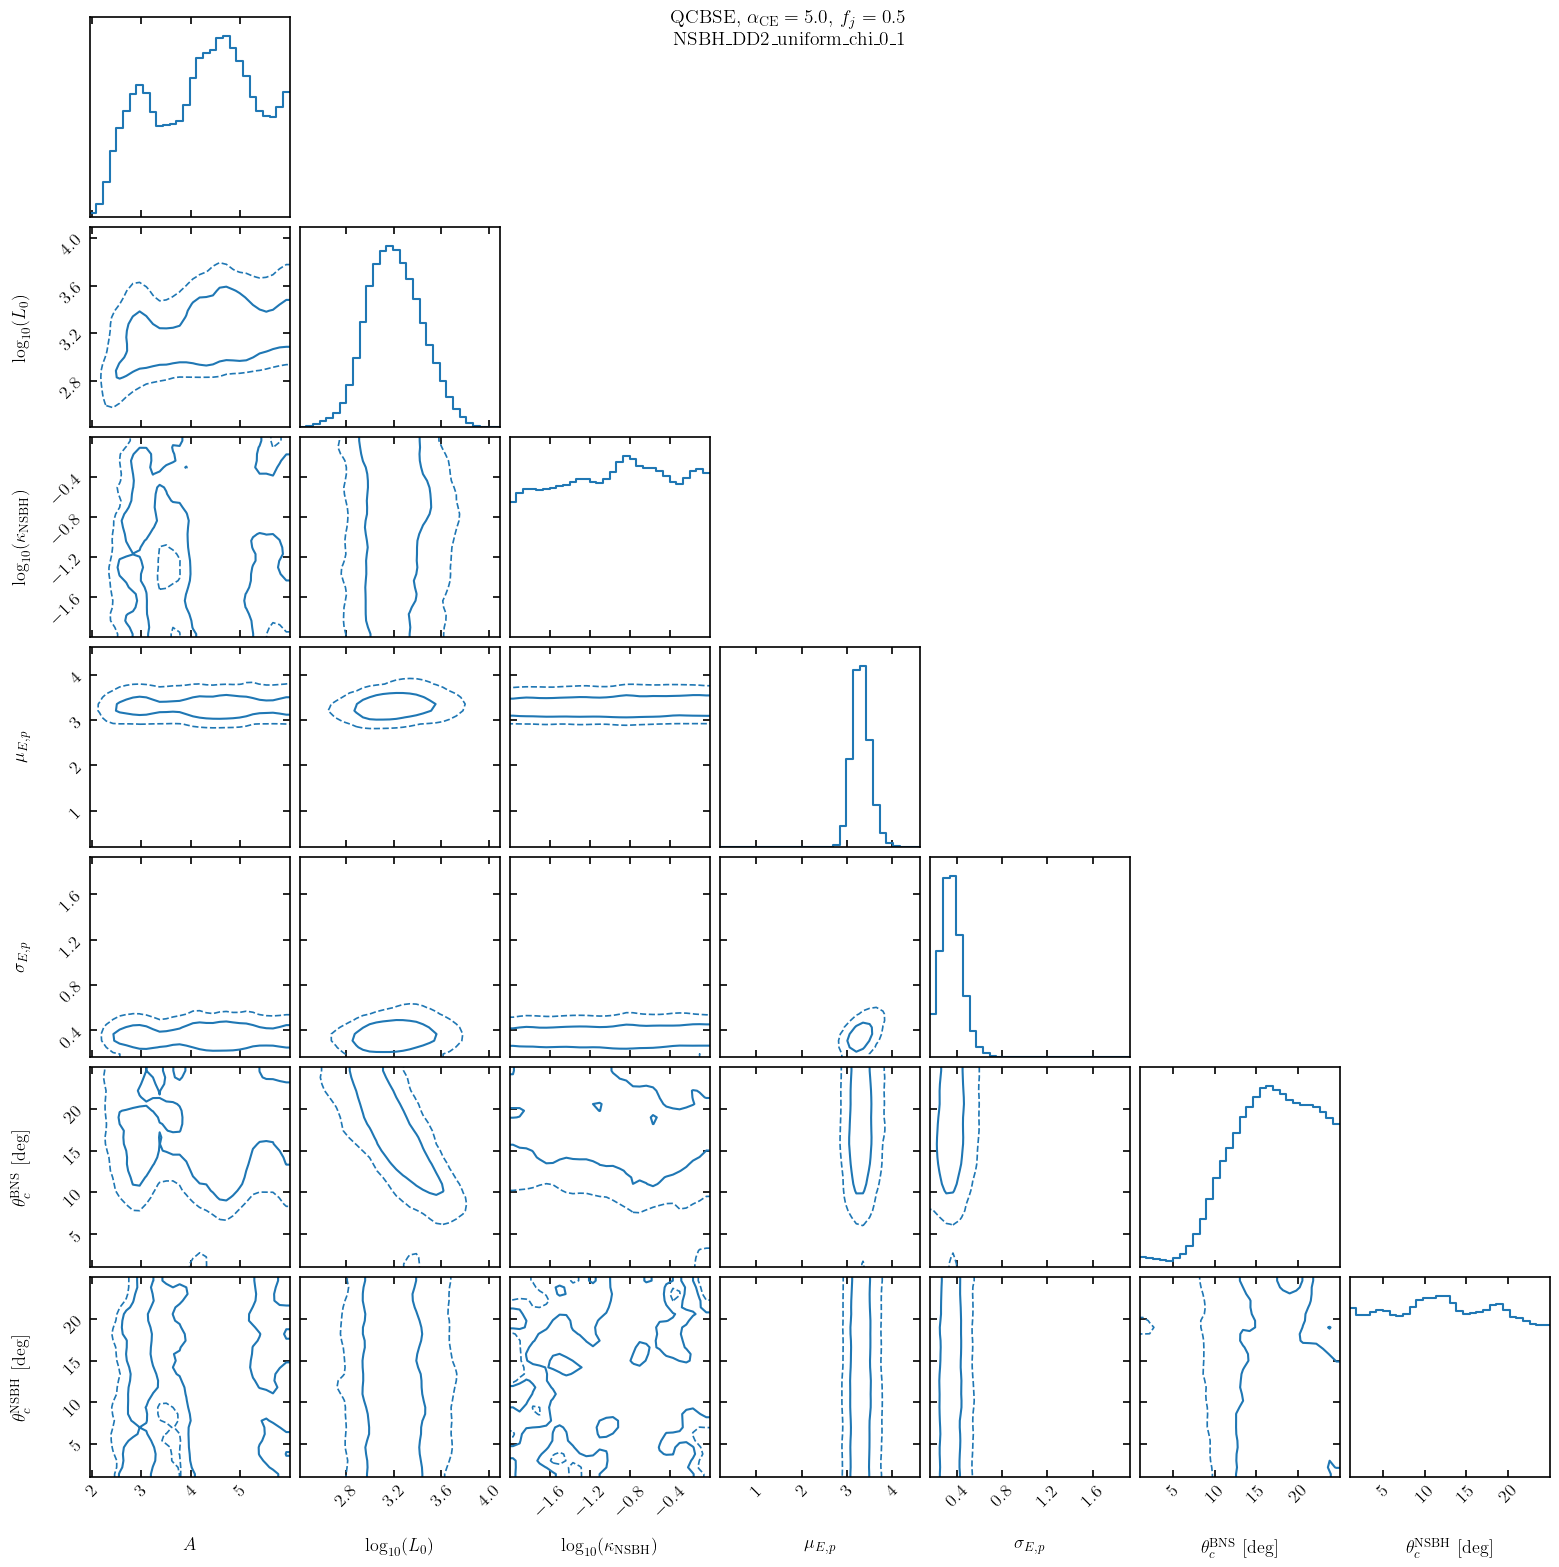

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1


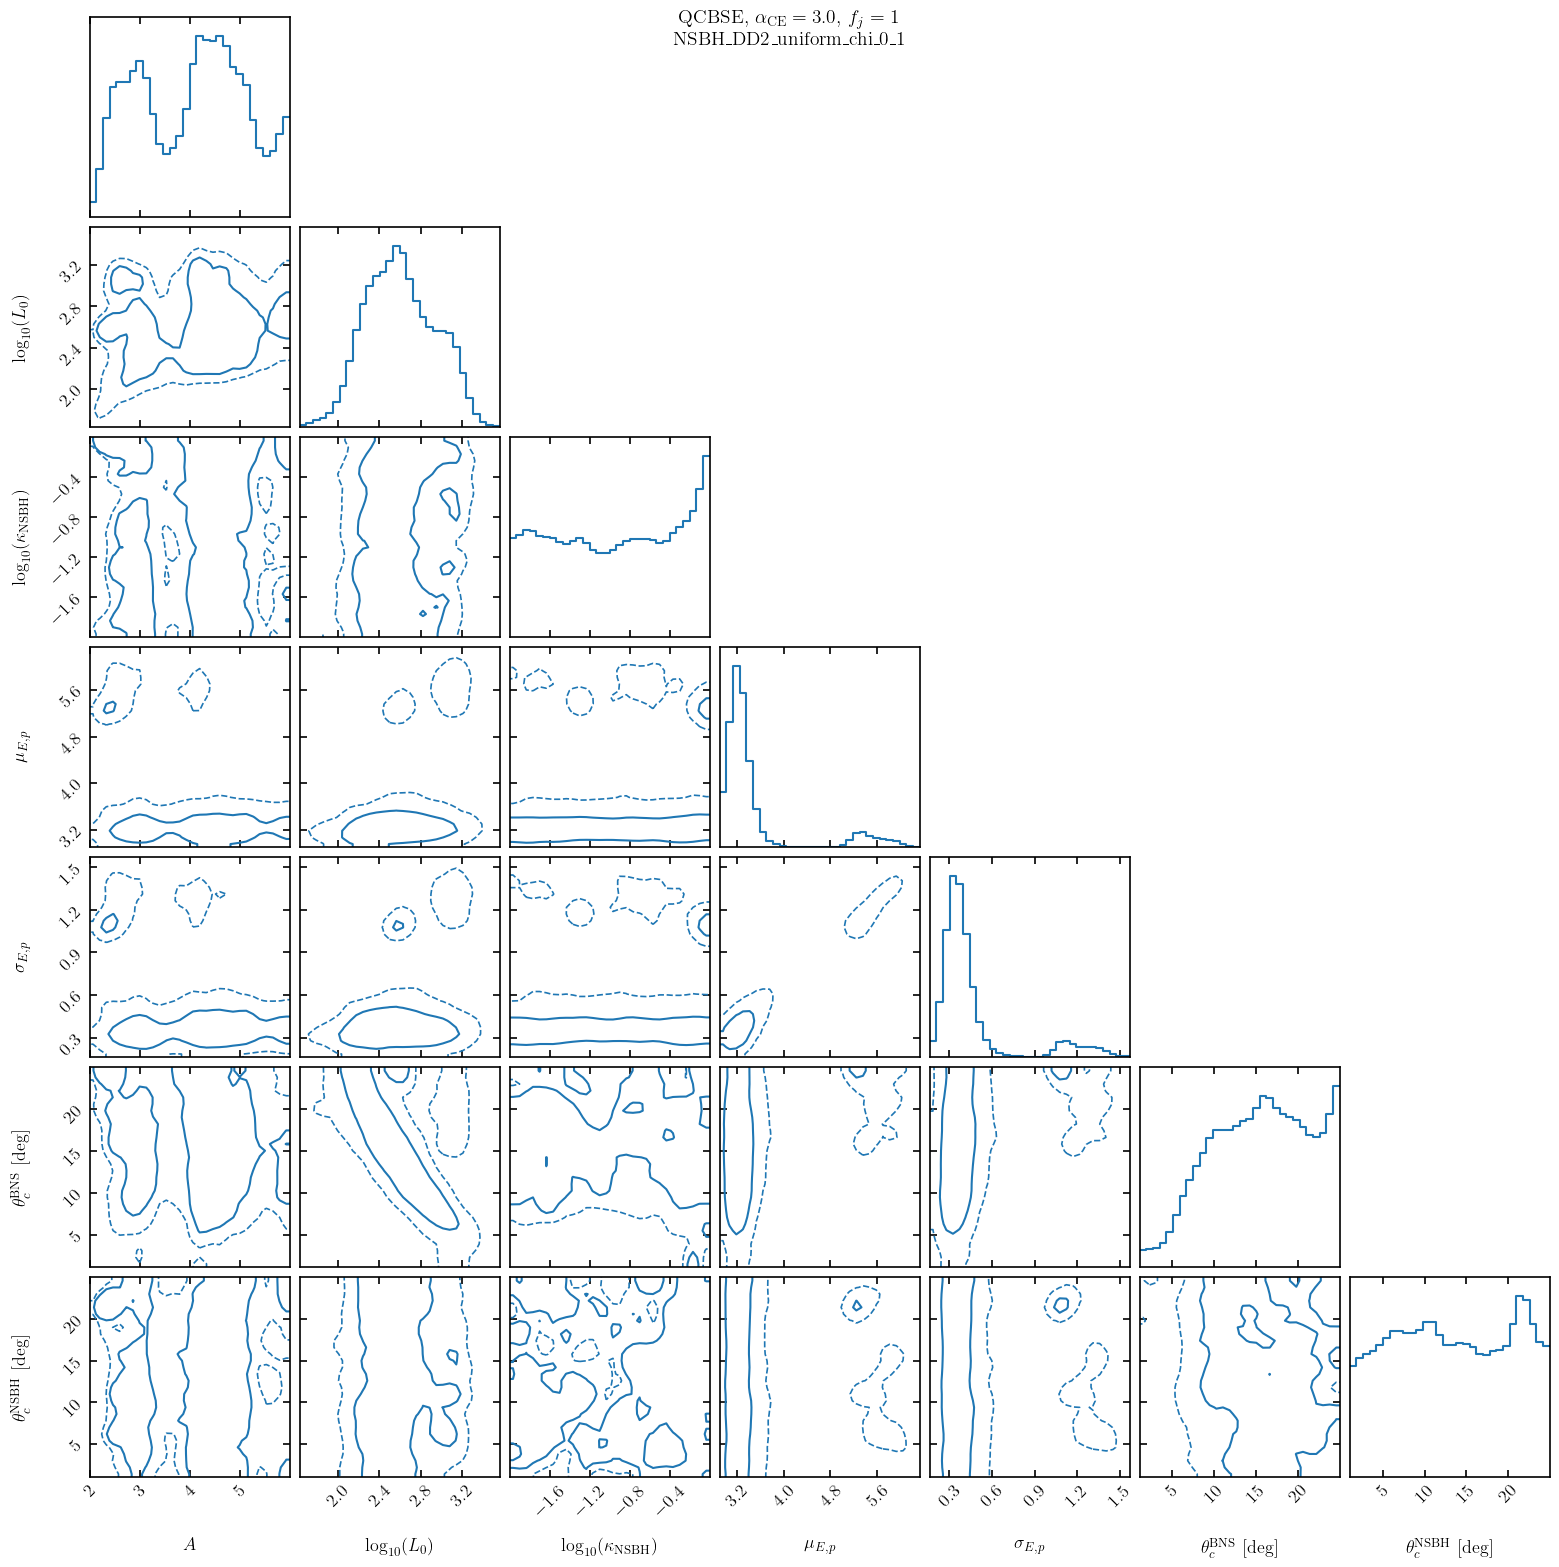

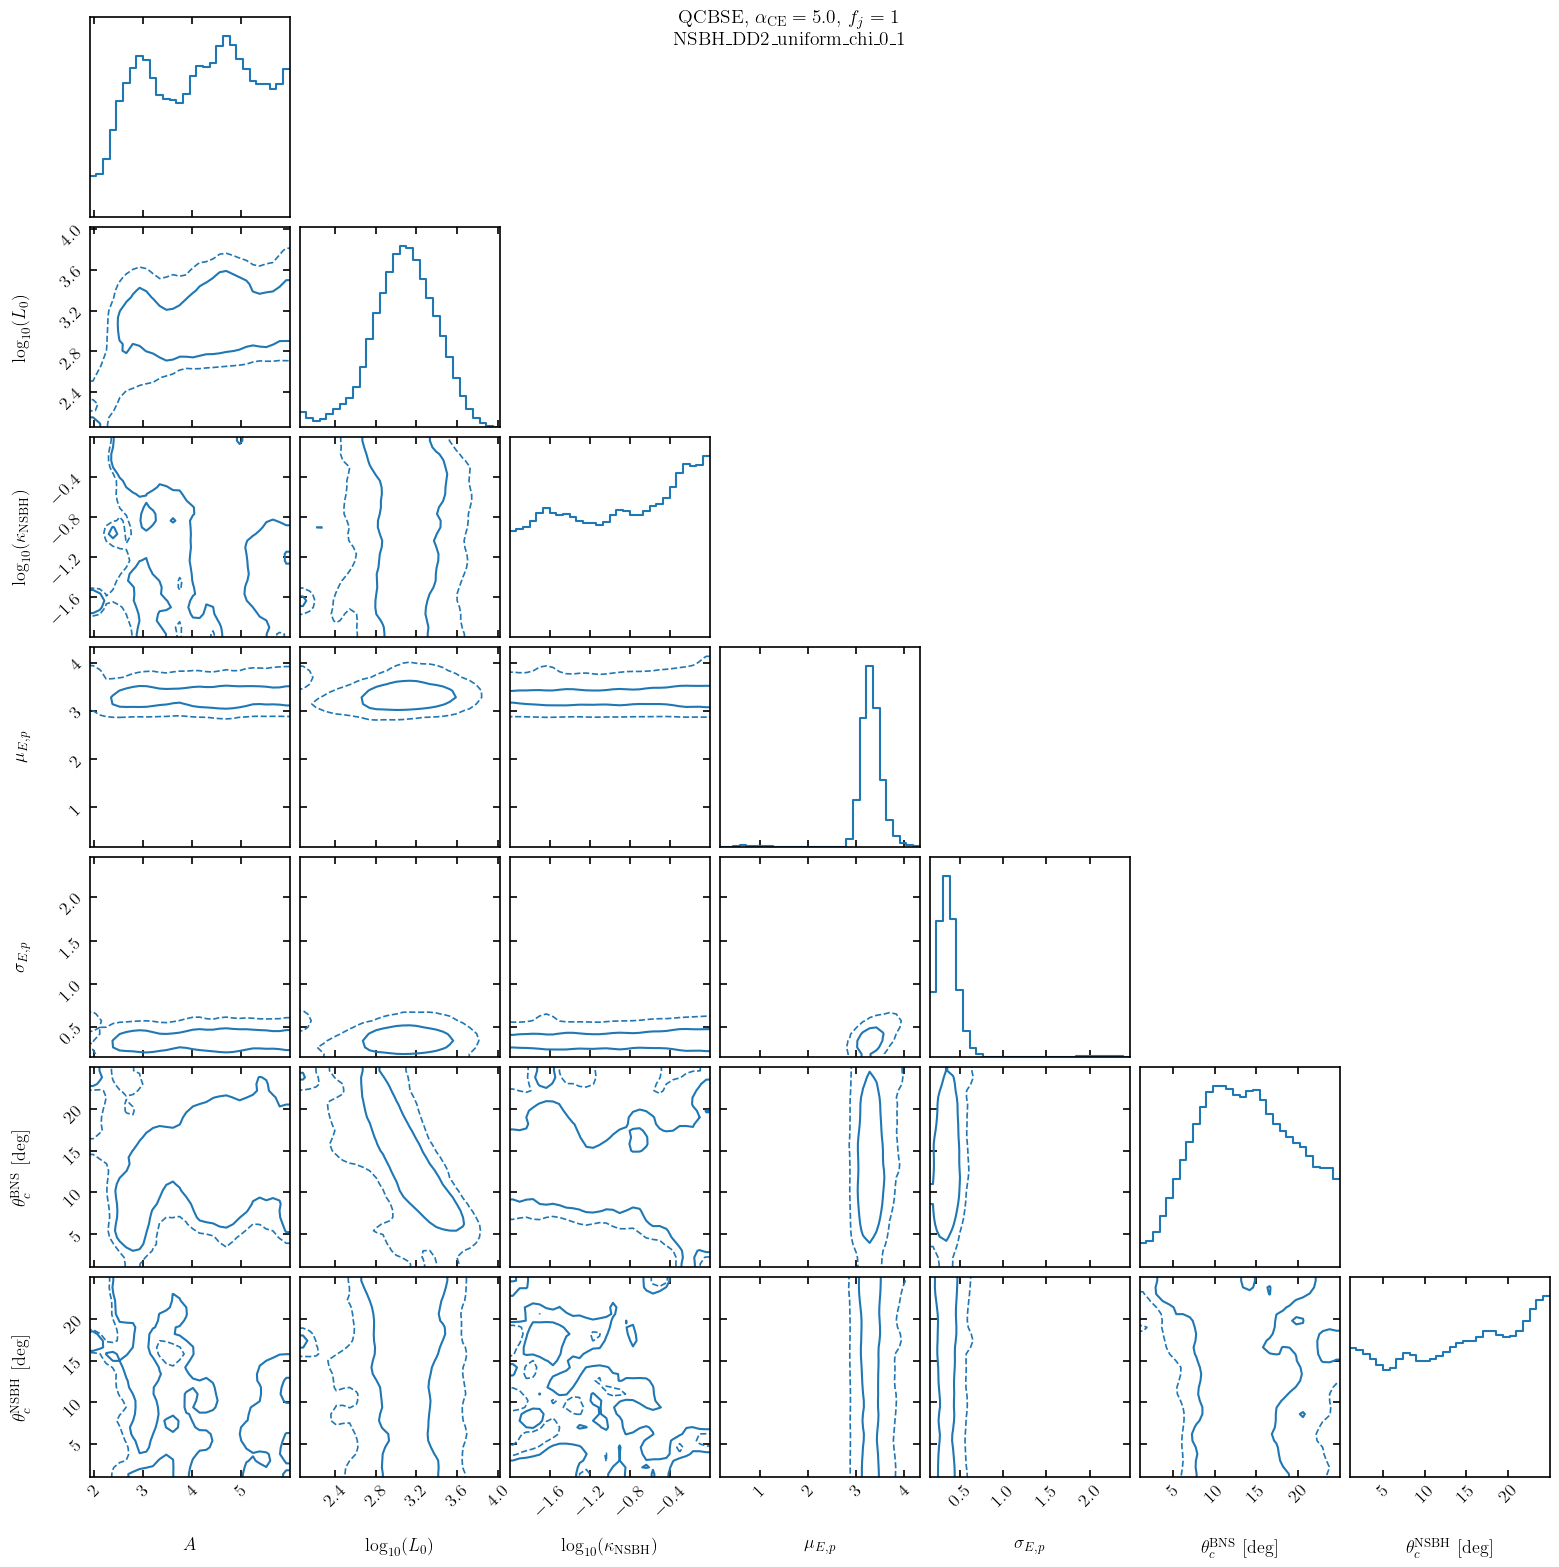

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


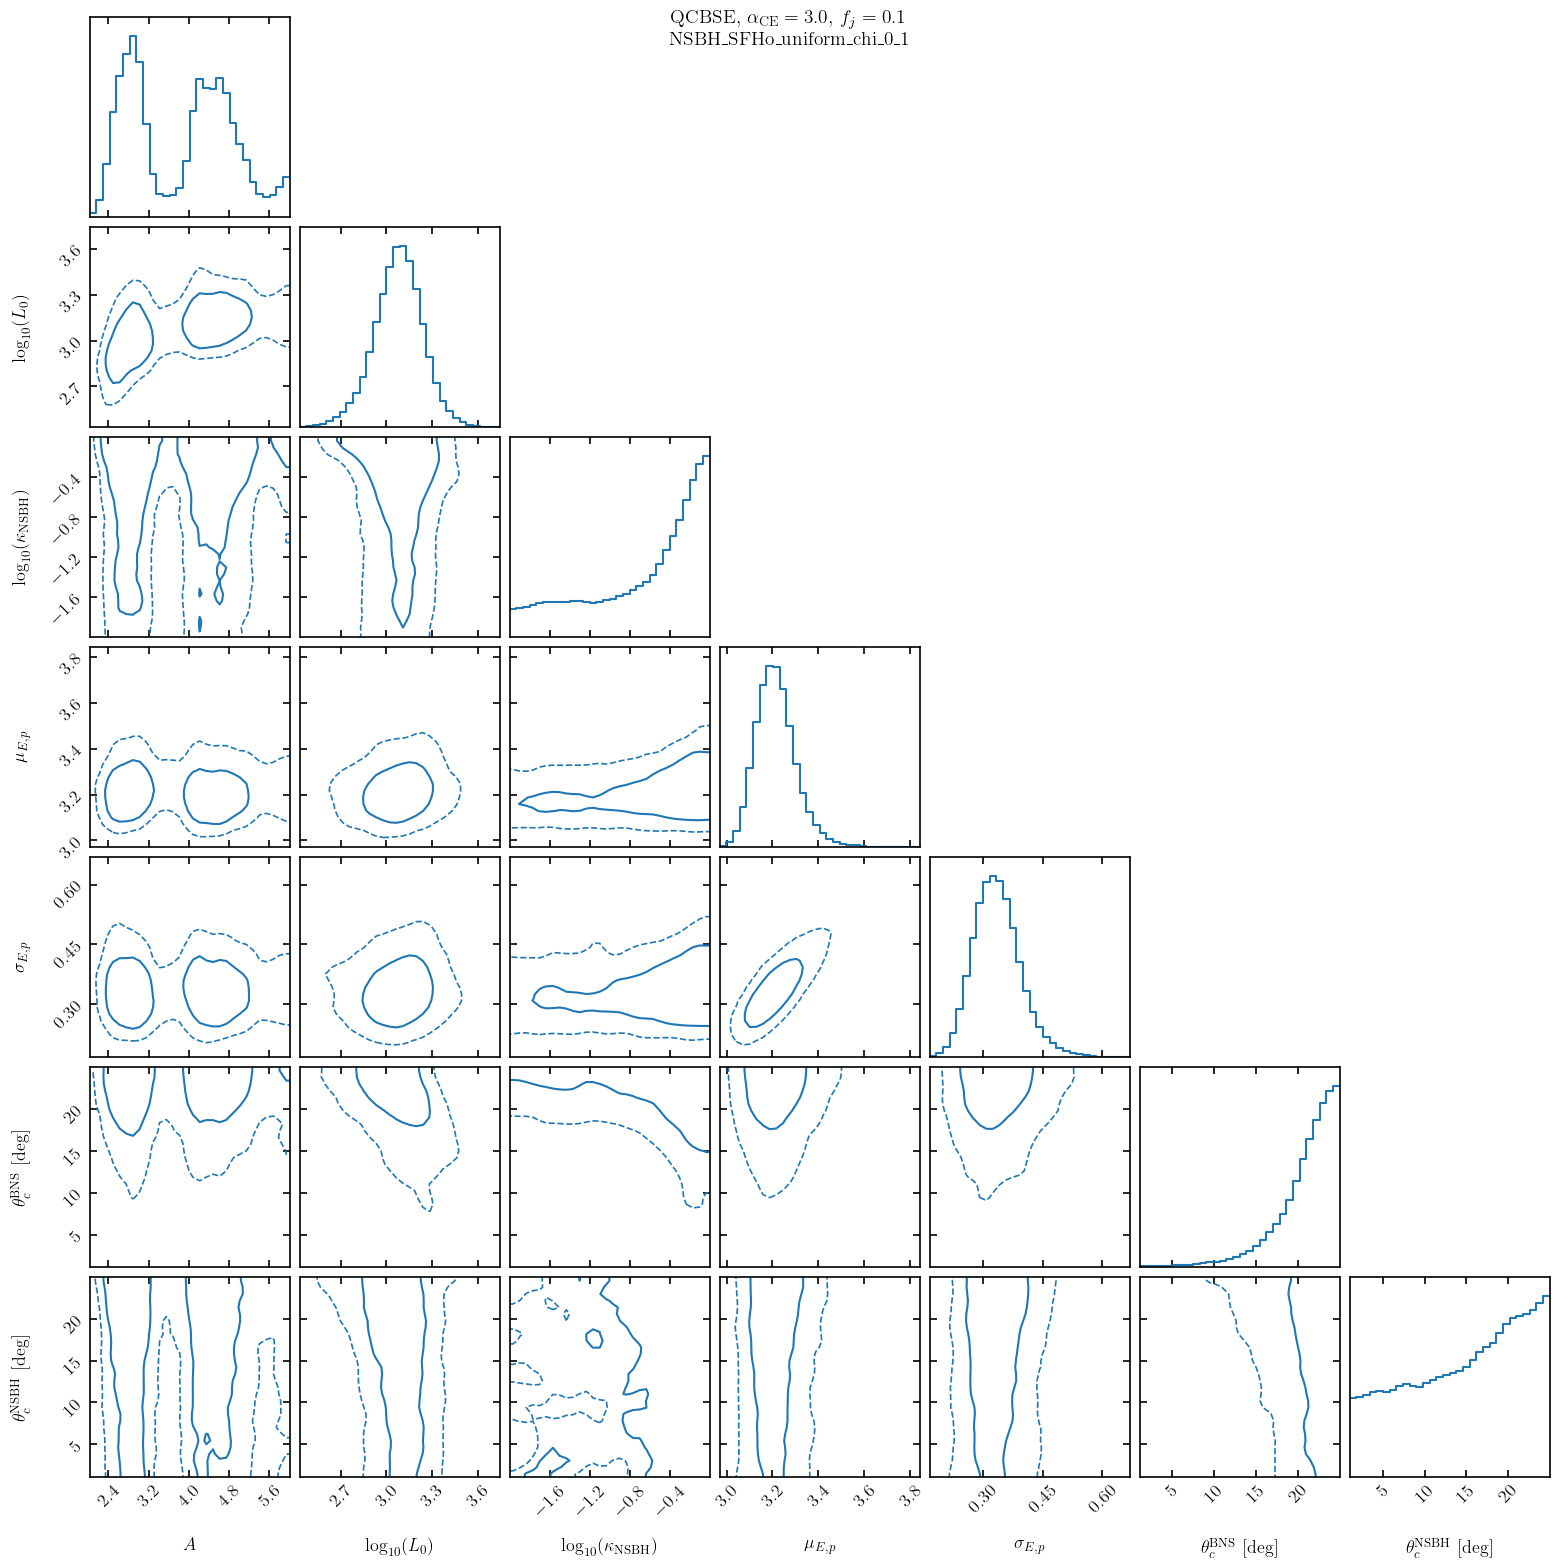

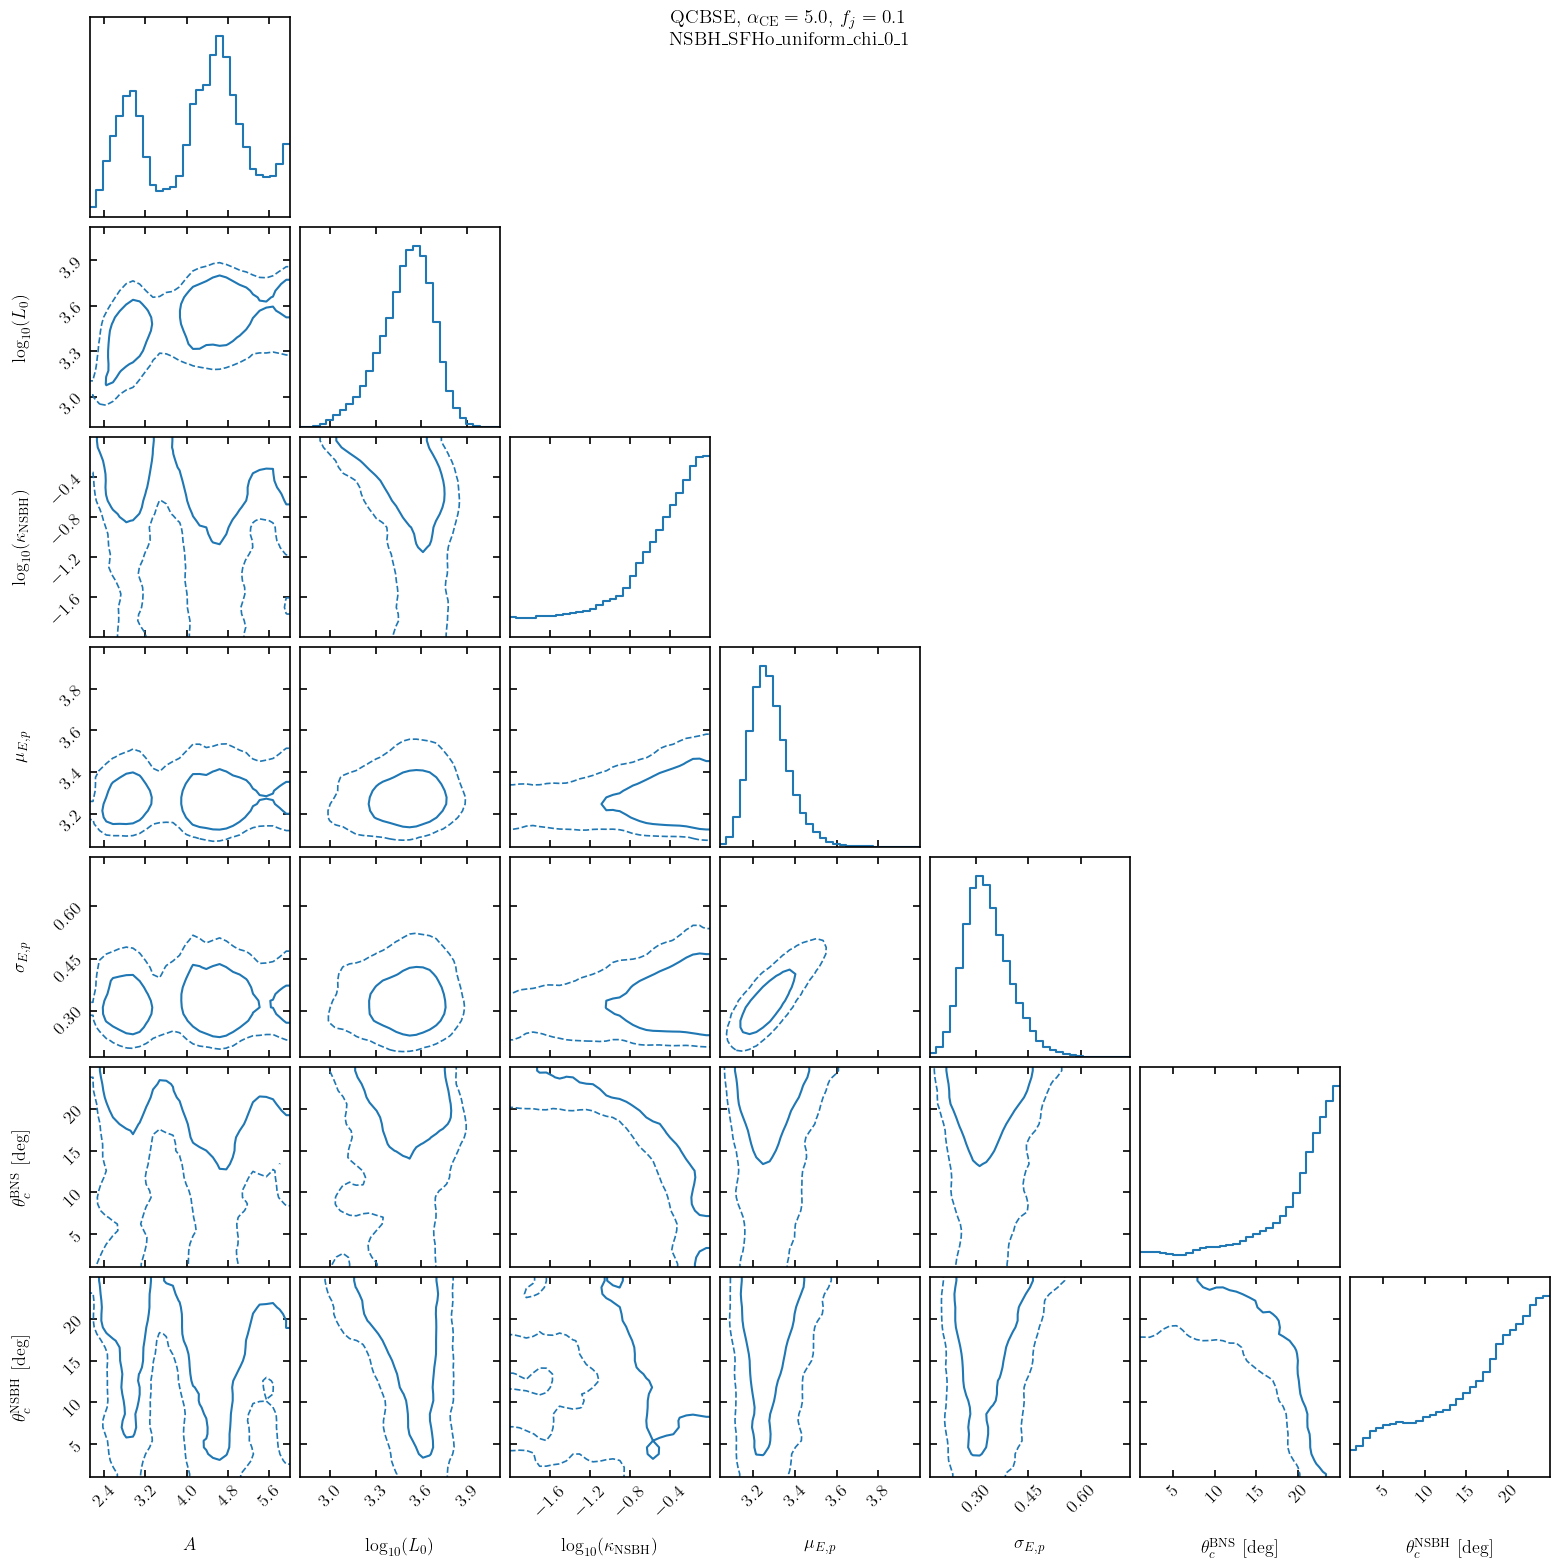

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


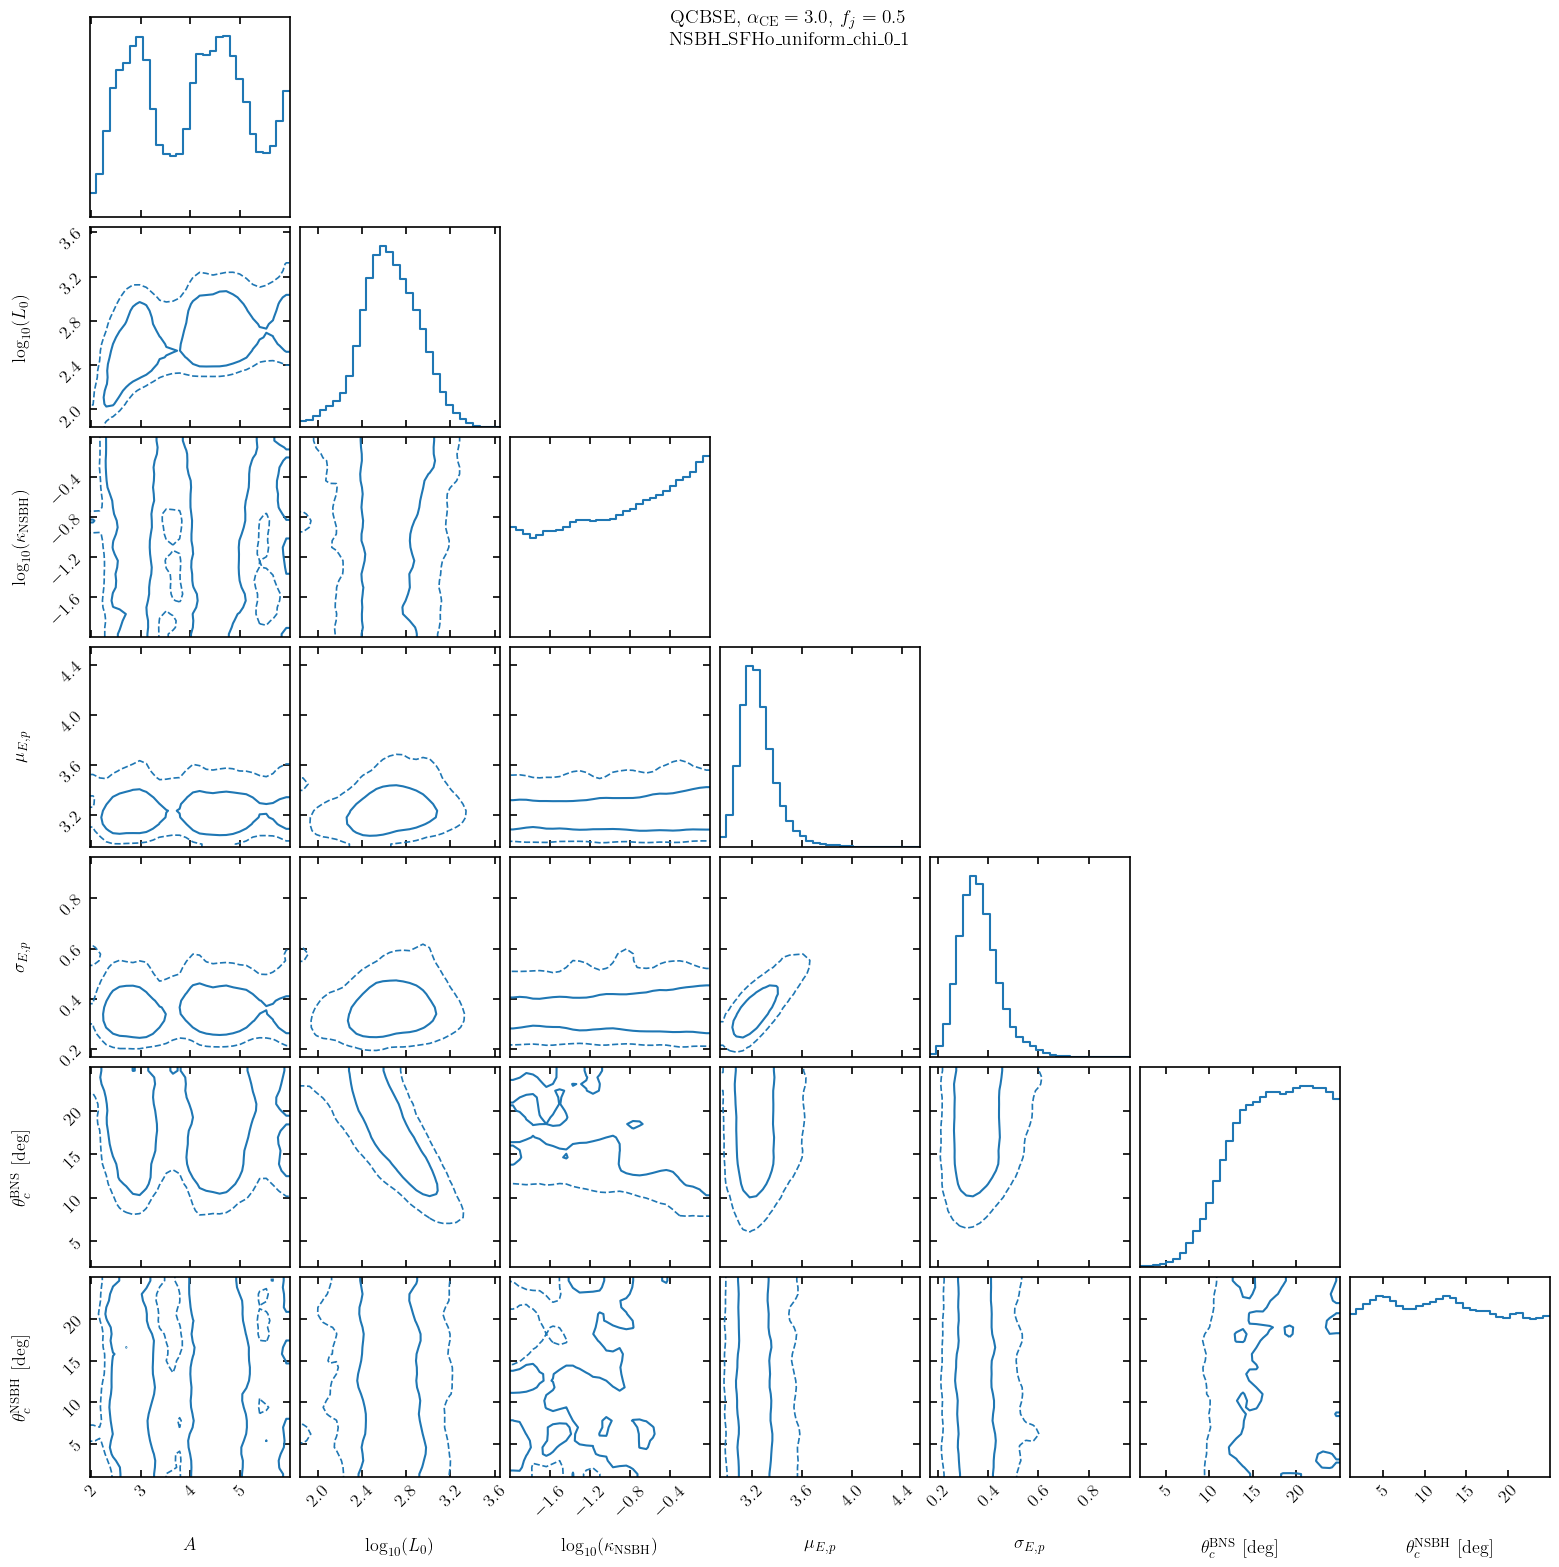

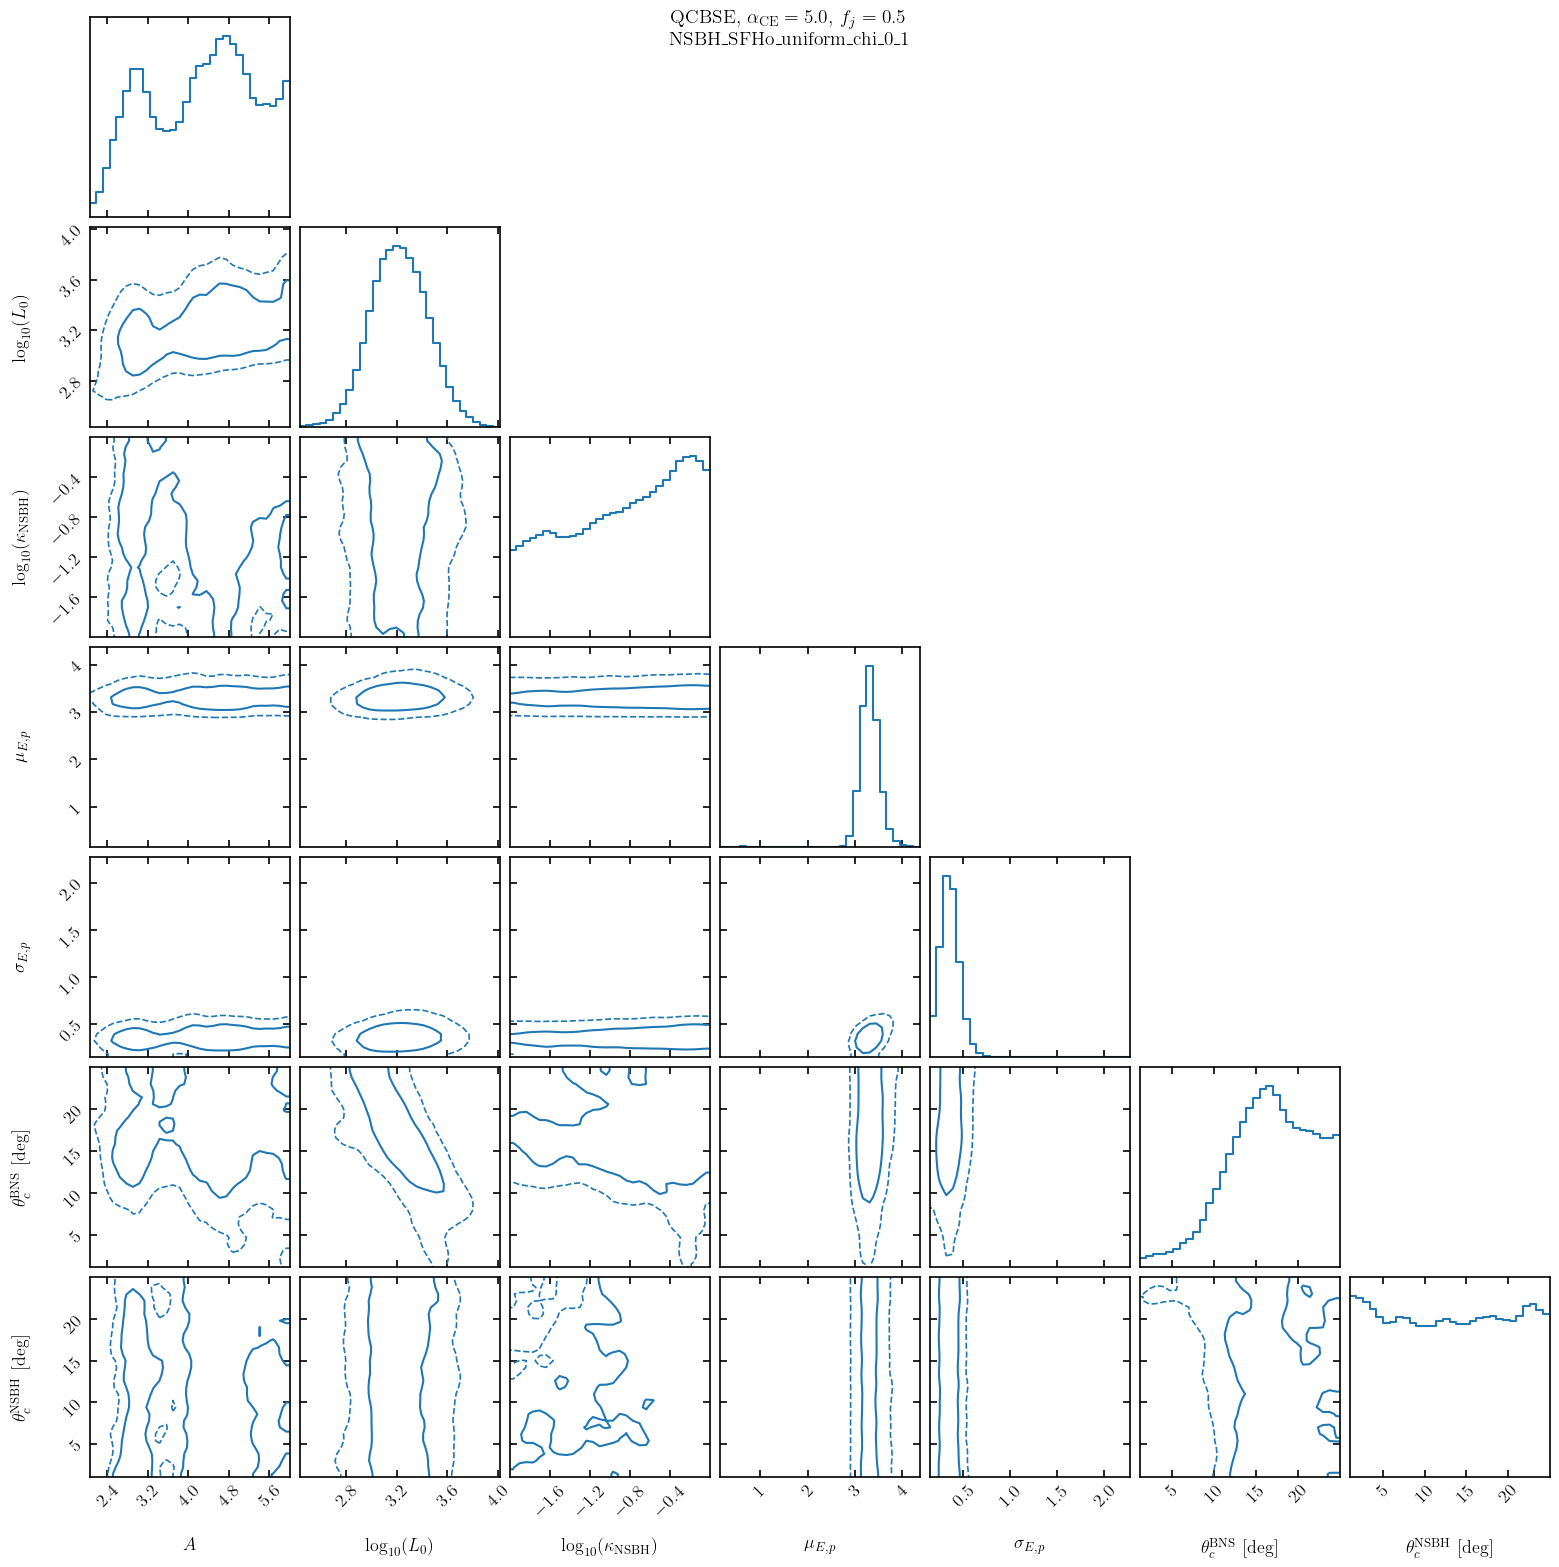

Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A5.0_fj_1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1


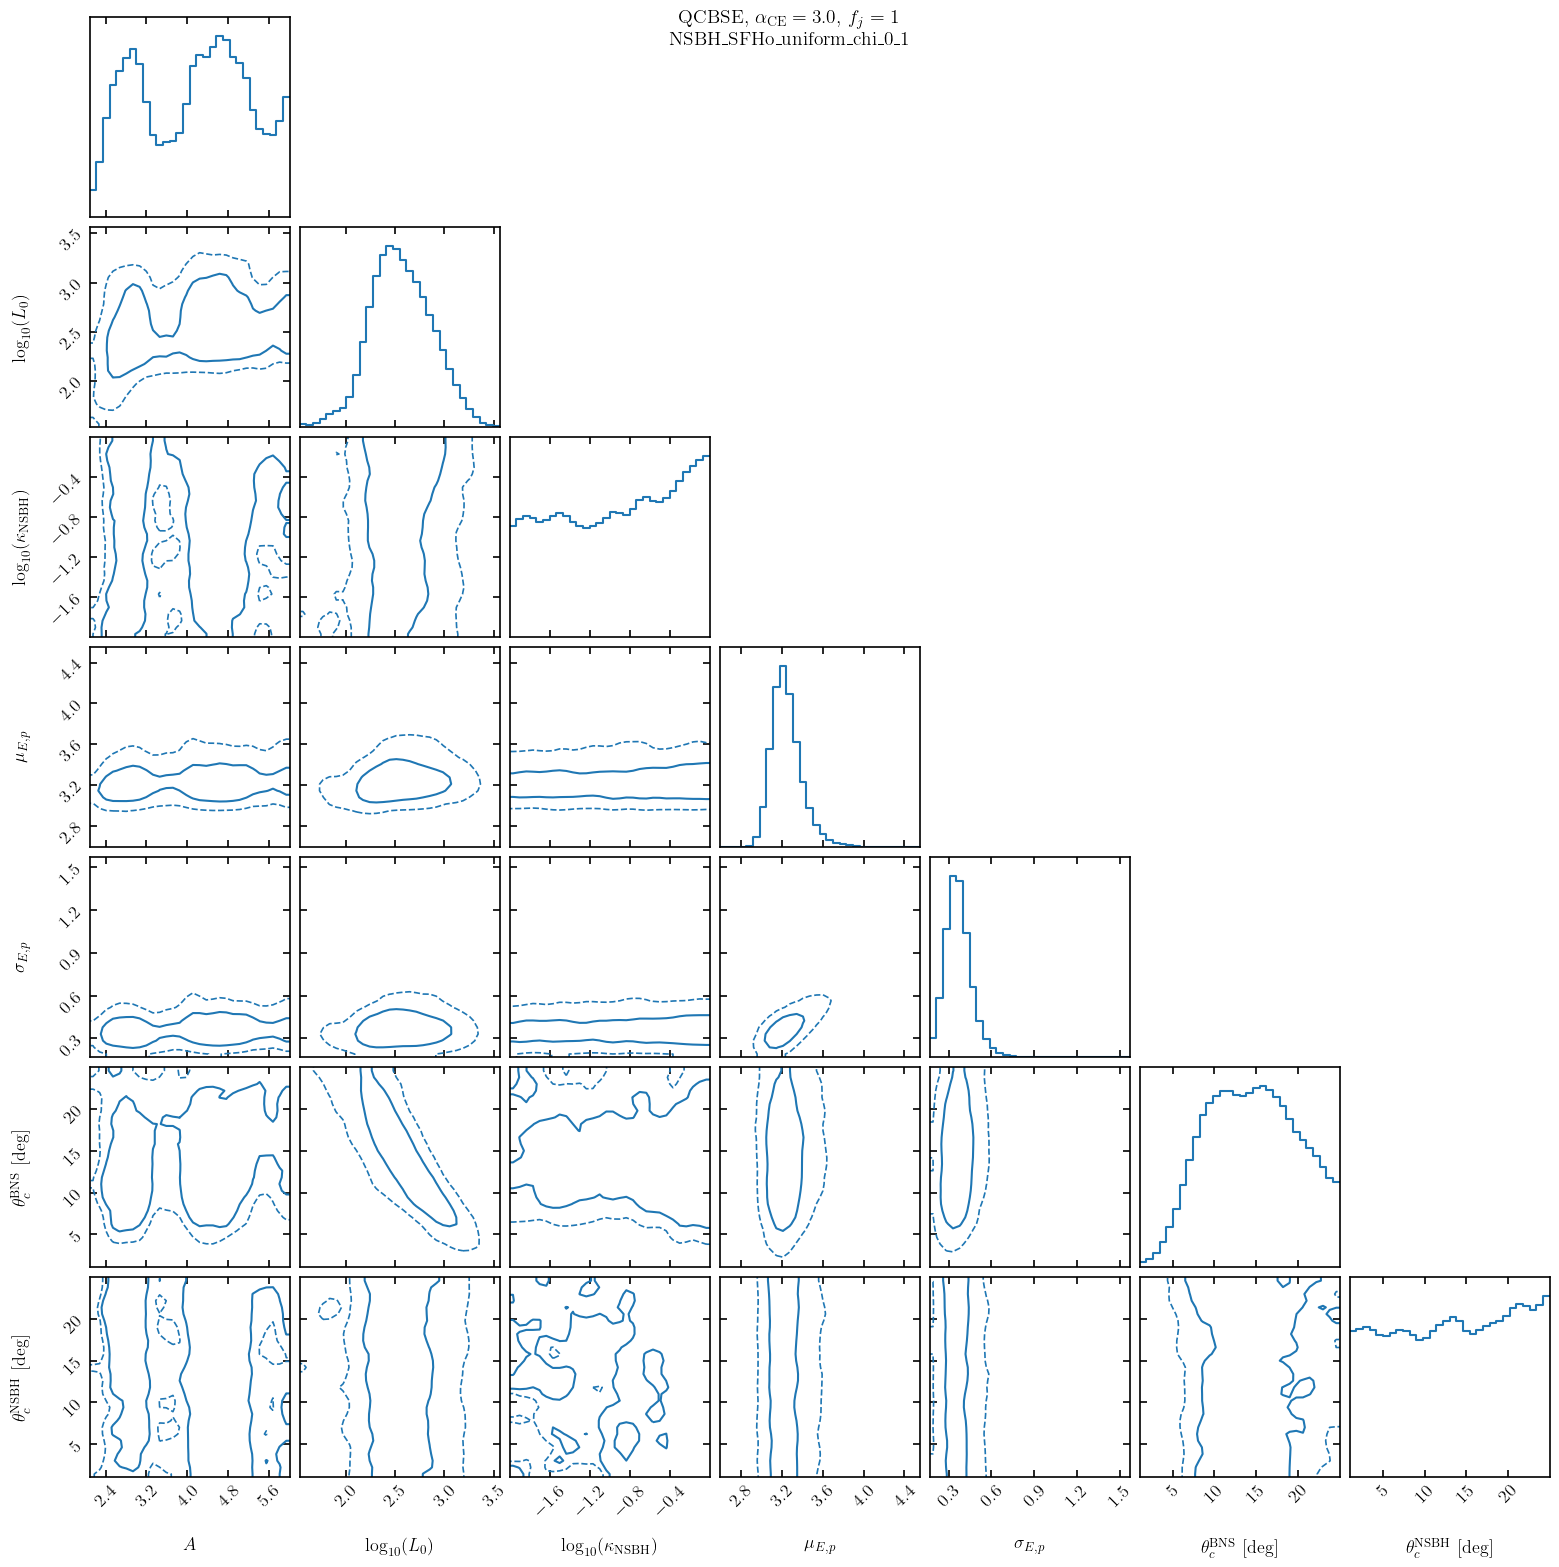

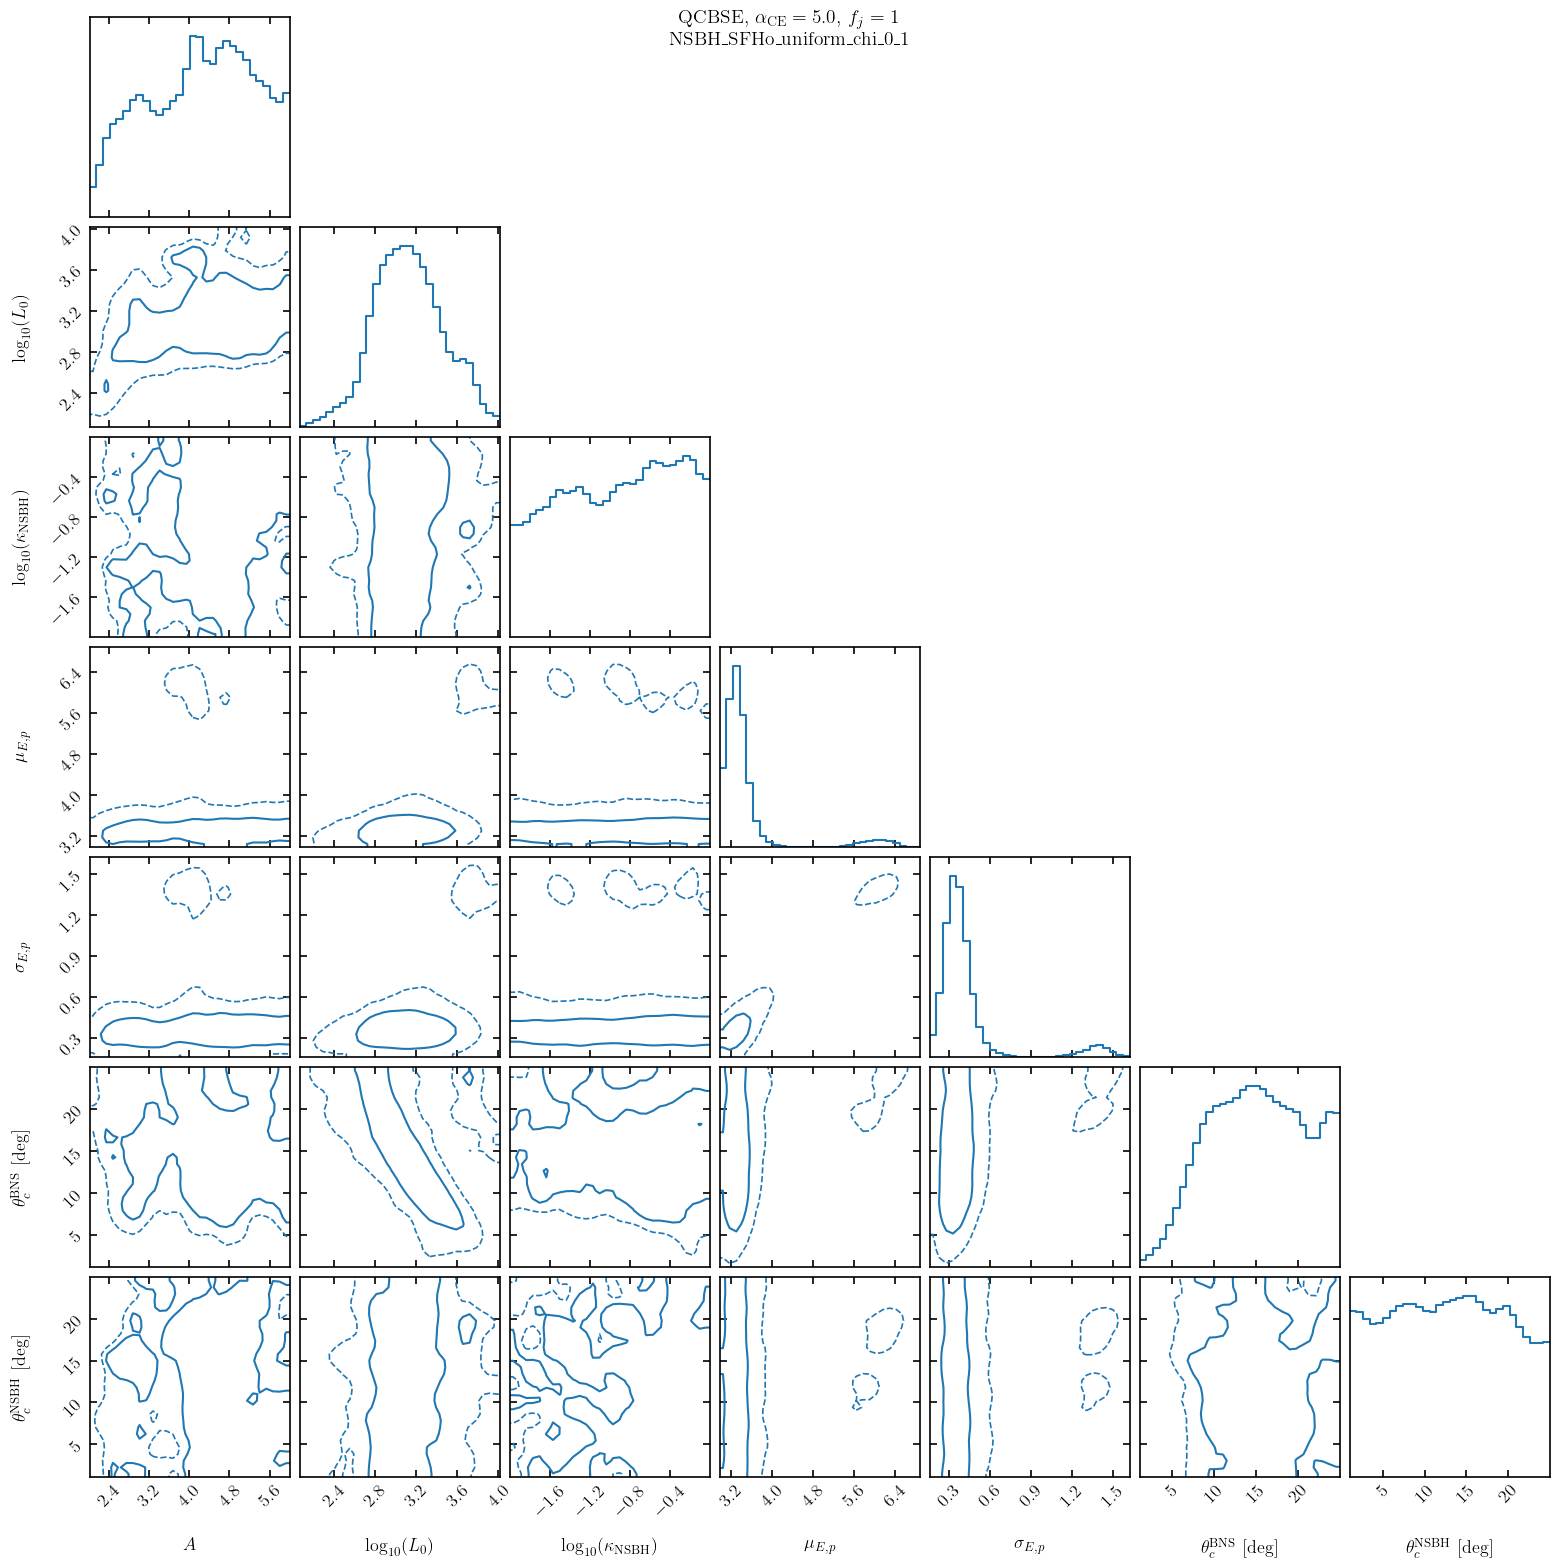

In [50]:
for nsbh_series in NSBH_SERIES:
    for fj_bns in FJ_LIST:
        figures = plot_corner(
            alphas=POSSIBLE_ALPHA,
            fj_bns=fj_bns,
            geom_eff_func=GEOM_EFF_FUNC,
            population=POPULATION,
            nsbh_series=nsbh_series,
            burn_frac=0.33,
            thin=10,
        )

        for alpha, fig in figures.items():
            output_name = (
                f"full_corner_{POPULATION}_{nsbh_series}_"
                f"{alpha}_fj_{fj_bns:g}_{GEOM_LABEL_CURRENT}.pdf"
            )

            fig.savefig(
                IMAGES_FOLDER / output_name,
                bbox_inches="tight",
            )
            plt.show()

In [51]:
print("Corner plots saved to:", IMAGES_FOLDER)
print("With names")
for nsbh_series in NSBH_SERIES:
    for fj_bns in FJ_LIST:
        for alpha in POSSIBLE_ALPHA:
            output_name = (
                f"full_corner_{POPULATION}_{nsbh_series}_"
                f"{alpha}_fj_{fj_bns:g}_{GEOM_LABEL_CURRENT}.pdf"
            )
            print(output_name)

Corner plots saved to: Images
With names
full_corner_qcbse_NSBH_DD2_uniform_chi_0_1_A3.0_fj_0.1_midpoint.pdf
full_corner_qcbse_NSBH_DD2_uniform_chi_0_1_A5.0_fj_0.1_midpoint.pdf
full_corner_qcbse_NSBH_DD2_uniform_chi_0_1_A3.0_fj_0.5_midpoint.pdf
full_corner_qcbse_NSBH_DD2_uniform_chi_0_1_A5.0_fj_0.5_midpoint.pdf
full_corner_qcbse_NSBH_DD2_uniform_chi_0_1_A3.0_fj_1_midpoint.pdf
full_corner_qcbse_NSBH_DD2_uniform_chi_0_1_A5.0_fj_1_midpoint.pdf
full_corner_qcbse_NSBH_SFHo_uniform_chi_0_1_A3.0_fj_0.1_midpoint.pdf
full_corner_qcbse_NSBH_SFHo_uniform_chi_0_1_A5.0_fj_0.1_midpoint.pdf
full_corner_qcbse_NSBH_SFHo_uniform_chi_0_1_A3.0_fj_0.5_midpoint.pdf
full_corner_qcbse_NSBH_SFHo_uniform_chi_0_1_A5.0_fj_0.5_midpoint.pdf
full_corner_qcbse_NSBH_SFHo_uniform_chi_0_1_A3.0_fj_1_midpoint.pdf
full_corner_qcbse_NSBH_SFHo_uniform_chi_0_1_A5.0_fj_1_midpoint.pdf


## Posterior rate-fraction grid

The runner saves predicted BNS and NSBH counts as blobs at every accepted sample. This cell converts them to yearly rates and plots $\eta_{\rm BNS}$ against $\eta_{\rm NSBH}$ for every fixed $f_j$ and $\alpha_{\rm CE}$.

In [52]:
rate_posteriors = collect_rate_posteriors(
    alphas=POSSIBLE_ALPHA,
    fj_list=FJ_LIST,
    population=POPULATION,
    nsbh_series=NSBH_SERIES,
    geom_eff_func=GEOM_EFF_FUNC,
    datafiles=DATAFILES,
    burn_frac=0.33,
    thin=10,
)

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
BNS: R(z=0.01)=34.05 Gpc^-3 yr^-1; all-sky rate=2.616e+04 yr^-1; MC sample=1
NSBH_DD2_uniform_chi_0_1: R(z=0.01)=5.06 Gpc^-3 yr^-1; all-sky rate=7.750e+03 yr^-1; MC sample=1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.1_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-DD2-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_0.5_geometric-efficiency-flat-midpoint_qcbse-NSBH-SFHo-uniform-chi-0-1
Loading existing directory  : Output_files/full_likelihood_alpha_A3.0_fj_

In [ ]:
fig, axes = plot_posterior_grid(
    dictionary_of_results=rate_posteriors,
    fj_list=FJ_LIST,
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=SERIES_LABELS,
    swap_axes=False,
    bins=40,
    levels=(0.68, 0.95),
    log_axes=True,
    minimum_fraction=5e-2,
)

#fig.savefig(
#    IMAGES_FOLDER / f"{POPULATION}_full_likelihood_posterior_grid_{GEOM_LABEL_CURRENT}.pdf",
#    bbox_inches="tight",
#)

plt.show()

1D fraction plot saved to: Images/qcbse_full_likelihood_fraction_1d.pdf


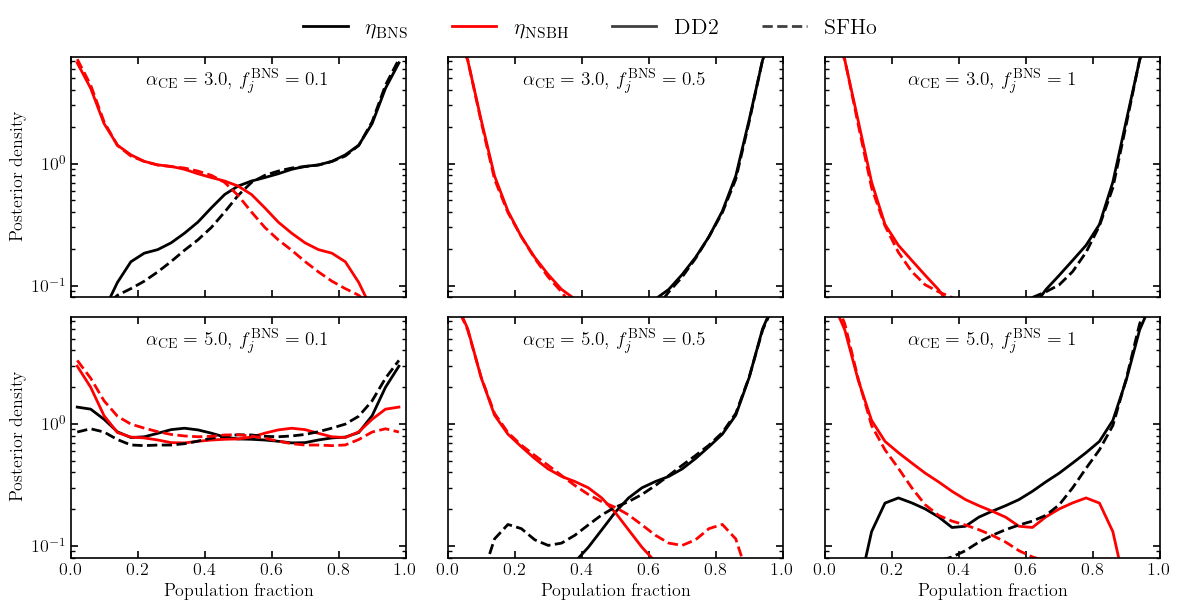

In [ ]:
from mcmc_runny import plot_fraction_1d

fj_list = [0.1, 0.5, 1.0]
fig_1d, axes_1d = plot_fraction_1d(
    rate_posteriors,
    fj_list=fj_list,
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=["DD2", "SFHo"],
    bins=25,
    smooth_sigma=1,
)

#save
fig_1d.savefig(
    IMAGES_FOLDER / f"{POPULATION}_full_likelihood_fraction_1d_{GEOM_LABEL_CURRENT}.pdf",
    bbox_inches="tight",
)

# geometry 
geometry_name = GEOM_EFF_FUNC.__name__
print("1D fraction plot saved to:", IMAGES_FOLDER / f"{POPULATION}_full_likelihood_fraction_1d.pdf")

plt.show()

In [42]:
from mcmc_runny import summarize_fraction_posteriors, format_fraction_summary_table

fraction_summary = summarize_fraction_posteriors(
    rate_posteriors,
    fj_list=FJ_LIST,
    alpha_list=POSSIBLE_ALPHA,
    nsbh_populations=NSBH_SERIES,
    population_labels=["DD2", "SFHo"],
    credible_level=0.90,
)

fraction_table = format_fraction_summary_table(
    fraction_summary,
    decimals=3,
)

display(fraction_table)

,alpha,fj_bns,EOS,"eta_NSBH (median, 90% CI)","eta_BNS (median, 90% CI)"
0,3.0,0.1,DD2,0.100 (+0.536/-0.099),0.900 (+0.099/-0.536)
1,3.0,0.1,SFHo,0.081 (+0.495/-0.081),0.919 (+0.081/-0.495)
2,3.0,0.5,DD2,0.006 (+0.161/-0.006),0.994 (+0.006/-0.161)
3,3.0,0.5,SFHo,0.005 (+0.145/-0.005),0.995 (+0.005/-0.145)
4,3.0,1.0,DD2,0.003 (+0.164/-0.003),0.997 (+0.003/-0.164)
5,3.0,1.0,SFHo,0.004 (+0.126/-0.004),0.996 (+0.004/-0.126)
6,5.0,0.1,DD2,0.461 (+0.500/-0.453),0.539 (+0.453/-0.500)
7,5.0,0.1,SFHo,0.345 (+0.597/-0.338),0.655 (+0.338/-0.597)
8,5.0,0.5,DD2,0.021 (+0.415/-0.020),0.979 (+0.020/-0.415)
9,5.0,0.5,SFHo,0.023 (+0.492/-0.022),0.977 (+0.022/-0.492)
